# 01 · Vektörler, Matrisler ve Lineer Dönüşümler
**Linear Algebra Lab** — Temel Notebook (Derinlemesine)

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Bu notebook, tüm serinin temelini oluşturuyor — buradaki sezgiyi sağlam kurmazsan,
> ilerideki eigenvalue/SVD/PCA notebook'ları soyut formüllerden ibaret kalır. Odak noktamız
> tek bir fikir: **bir matris, bir sayı tablosu değil, vektörleri DÖNÜŞTÜREN bir
> makinedir.** Bu fikri kavradığında, `numpy`'da her gün yazdığın `A @ x` işleminin aslında
> ne yaptığını GERÇEKTEN anlamış olacaksın — kod yazarken artık "büyü" değil, geometri
> göreceksin.

**Önkoşul:** Yok — bu, serinin ilk ve en temel notebook'u  
**Veri:** Sentetik 2D noktalar/şekiller (`numpy` ile üretilen) — bu konuda gerçek veri
yerine kontrollü geometrik şekiller kullanmak bilinçli bir tercih: matrisin TAM OLARAK
neyi nasıl değiştirdiğini net görebilmek için neyin dönüştüğünü baştan bilmen gerekiyor  
**Araçlar:** Python (`numpy`, `matplotlib`)

---
## 1 · Vektör Nedir?

Bir vektör, iki eşdeğer şekilde düşünülebilir:

- **Geometrik olarak:** Bir **yön** ve bir **büyüklük** (uzunluk). 2D'de bir ok gibi düşün —
  orijinden başlayıp bir noktaya giden bir çizgi.
- **Cebirsel olarak:** Bir sayı listesi, örn. $\vec{v} = \begin{bmatrix}3\\4\end{bmatrix}$ —
  "orijinden 3 birim sağa, 4 birim yukarı git" demek.

**Kritik nokta:** Bu iki bakış açısı **aynı şeyi** anlatıyor — kod yazarken hep cebirsel
(sayı listesi) tarafını görürsün, ama sezgini kaybetmemek için hep geometrik tarafı aklında
tut. `numpy`'da bir vektör, basitçe 1 boyutlu bir array.

---
## 2 · Vektör İşlemleri: Toplama, Çıkarma, Skaler Çarpım

**Toplama — geometrik anlamı "uç uca ekleme":**
$$\vec{u}+\vec{v} = \begin{bmatrix}u_1+v_1\\u_2+v_2\end{bmatrix}$$
$\vec{u}$'yu çiz, sonra $\vec{v}$'yi $\vec{u}$'nun UCUNDAN başlatarak çiz — toplam, orijinden
$\vec{v}$'nin yeni ucuna giden ok.

**Skaler çarpım — geometrik anlamı "uzatma/kısaltma":**
$$c\vec{v} = \begin{bmatrix}cv_1\\cv_2\end{bmatrix}$$
$c>1$ ise vektör uzar, $0<c<1$ ise kısalır, $c<0$ ise TERS yöne döner.

**Somut sayısal örnek:** $\vec{u}=[3,1]$, $\vec{v}=[1,2]$ olsun.
$$\vec{u}+\vec{v} = [4,3] \qquad 2\vec{u} = [6,2] \qquad -\vec{v} = [-1,-2]$$

---
## 3 · İç Çarpım (Dot Product): Açı ve Projeksiyon

$$\vec{u}\cdot\vec{v} = u_1v_1+u_2v_2 = \|\vec{u}\|\|\vec{v}\|\cos\theta$$

İki farklı formül, aynı sayıyı veriyor — biri hesaplaması kolay (cebirsel), diğeri sezgiyi
veriyor (geometrik, aradaki AÇI ile ilişkili).

**Sezgisi:** İç çarpım, "$\vec{u}$'nun ne kadarı $\vec{v}$ yönünde" sorusuna cevap veriyor.

- $\vec{u}\cdot\vec{v} > 0$ → aralarındaki açı $90°$'den küçük (aynı genel yöne bakıyorlar)
- $\vec{u}\cdot\vec{v} = 0$ → **dik (ortogonal)** — birbirini hiç "desteklemiyorlar"
- $\vec{u}\cdot\vec{v} < 0$ → açı $90°$'den büyük (zıt yönlere bakıyorlar)

**Somut sayısal örnek:** $\vec{u}=[3,1]$, $\vec{v}=[1,2]$:
$$\vec{u}\cdot\vec{v} = 3(1)+1(2) = 5$$
$$\|\vec{u}\|=\sqrt{10},\ \|\vec{v}\|=\sqrt{5} \Rightarrow \cos\theta = \frac{5}{\sqrt{10}\sqrt{5}} = \frac{5}{\sqrt{50}} \approx 0.707 \Rightarrow \theta \approx 45°$$

**Neden önemli (ML bağlantısı):** Kosinüs benzerliği (cosine similarity — metin/öneri
sistemlerinde her yerde kullanılan bir metrik) tam olarak bu $\cos\theta$ değeridir.

### 3.1 Skaler ve Vektörel İzdüşüm

- Bir $(vec{a})$ vektörünün $(vec{b})$ vektörü üzerindeki izdüşümü, $(vec{a})$'nın ucundan $(vec{b})$'nin doğrultusuna dikme indirildiğinde oluşan gölge vektörüdür.
- Skaler izdüşüm uzunluk verirken, vektörel izdüşüm $(vec{b})$ yönünde bir yeni vektör oluşturur. Formüller ve çeşitler aşağıdadır.

#### İzdüşüm Çeşitleri ve Formülleri

**Skaler İzdüşüm (Büyüklük):** $$\text{comp}_{\vec{b}}\vec{a} = \frac{\vec{a} \cdot \vec{b}}{\vert{}\vec{b}\vert{}}$$

$(vec{a})$'nın $(vec{b})$ üzerindeki izdüşümünün boyudur. 
İşaretli bir sayı veya uzunluk belirtir.

**Vektörel İzdüşüm (Vektör):** $$\text{proj}_{\vec{b}}\vec{a} = \left( \frac{\vec{a} \cdot \vec{b}}{\vert{}\vec{b}\vert{}^2} \right) \vec{b} = \left( \frac{\vec{a} \cdot \vec{b}}{\vec{b} \cdot \vec{b}} \right) \vec{b}$$

Skaler izdüşüm büyüklüğünün $(vec{b})$'nin birim vektörüyle çarpımıyla bulunan vektördür.


---
## 4 · Matris Nedir? Bir "Dönüşüm Makinesi" Olarak Düşün

Bir matris, sayılardan oluşan bir tablo — ama asıl önemli olan, bir matrisin bir vektörle
çarpıldığında **onu başka bir vektöre dönüştürmesi.** $2\times 2$ bir matris:
$$A = \begin{bmatrix}a & b\\c & d\end{bmatrix}$$

Bunu bir vektörle çarptığında ($A\vec{v}$), $\vec{v}$'yi **yeni bir vektöre** taşıyorsun.
Bu, tüm serinin en kritik fikri: **matris = fonksiyon, girdi = vektör, çıktı = dönüştürülmüş vektör.**

---
## 5 · Matris Çarpımı = Lineer Dönüşüm (KRİTİK SEZGİ, Adım Adım)

$$A\vec{v} = \begin{bmatrix}a & b\\c & d\end{bmatrix}\begin{bmatrix}v_1\\v_2\end{bmatrix} = \begin{bmatrix}av_1+bv_2\\cv_1+dv_2\end{bmatrix}$$

**Somut sayısal örnek:** $A=\begin{bmatrix}2 & 0\\0 & 3\end{bmatrix}$, $\vec{v}=[1,1]$:

$$A\vec{v} = \begin{bmatrix}2(1)+0(1)\\0(1)+3(1)\end{bmatrix} = \begin{bmatrix}2\\3\end{bmatrix}$$

$\vec{v}=[1,1]$ vektörü $[2,3]$'e dönüştü — x-yönünde 2 kat, y-yönünde 3 kat uzadı. Bu $A$
matrisi bir **ölçekleme (scaling)** dönüşümü.

**En derin sezgi — matrisin SÜTUNLARI, temel eksenlerin NEREYE gittiğini gösteriyor:**
$$A\begin{bmatrix}1\\0\end{bmatrix} = \begin{bmatrix}a\\c\end{bmatrix} \text{(matrisin 1. sütunu)} \qquad A\begin{bmatrix}0\\1\end{bmatrix} = \begin{bmatrix}b\\d\end{bmatrix} \text{(matrisin 2. sütunu)}$$

Yani bir matrisin sütunlarına bakarak, "x-ekseni nereye gidiyor, y-ekseni nereye gidiyor"
sorusunu doğrudan cevaplayabilirsin — bu, ileride eigenvalue/eigenvector'ü anlarken
kullanacağın temel sezgi.

---
## 6 · Özel Dönüşümler: Rotasyon, Ölçekleme, Shear, Yansıma

| Dönüşüm | Matris | Etkisi |
|---|---|---|
| **Ölçekleme** | $\begin{bmatrix}s_x & 0\\0 & s_y\end{bmatrix}$ | x/y eksenlerini bağımsız olarak büyütür/küçültür |
| **Rotasyon** ($\theta$ derece) | $\begin{bmatrix}\cos\theta & -\sin\theta\\\sin\theta & \cos\theta\end{bmatrix}$ | Orijin etrafında $\theta$ kadar döndürür |
| **Shear (Eğme)** | $\begin{bmatrix}1 & k\\0 & 1\end{bmatrix}$ | Bir ekseni sabit tutup diğerini "eğer" (dikdörtgeni paralelkenara çevirir) |
| **Yansıma (x-ekseni)** | $\begin{bmatrix}1 & 0\\0 & -1\end{bmatrix}$ | y-koordinatının işaretini ters çevirir (ayna görüntüsü) |

Bu dört matris, bilgisayar grafikleri, görüntü işleme ve robotik gibi alanlardaki HER
geometrik işlemin temel yapı taşı — Python bölümünde hepsini görsel olarak deneyeceğiz.

---
## 7 · Determinant: "Alan/Hacim Ölçekleme Faktörü"

$2\times 2$ bir matrisin determinantı:
$$\det(A) = ad-bc$$

**Geometrik anlamı (çok kritik):** Determinant, dönüşümün **alanı kaç kat büyüttüğünü/
küçülttüğünü** söylüyor. Birim kareyi (alan=1) $A$ ile dönüştürürsen, yeni şeklin alanı
TAM OLARAK $|\det(A)|$ olur.

**Somut sayısal örnek:** $A=\begin{bmatrix}2&0\\0&3\end{bmatrix}$ için $\det(A)=2(3)-0(0)=6$.
Birim kare (alan=1), bu dönüşümden sonra $2\times 3=6$ birimlik bir dikdörtgene dönüşüyor —
tam olarak determinantın öngördüğü gibi!

**İşaretin anlamı:** $\det(A)<0$ ise, dönüşüm bir **yansıma** içeriyor demektir (şeklin
"içi dışına" çıkıyor — saat yönü tersine dönüyor). $\det(A)=0$ ise, dönüşüm şekli **düzleştiriyor**
(2D'den 1D'ye, bir çizgiye sıkıştırıyor) — alan sıfıra iniyor, bu da Bölüm 8'in temelini oluşturuyor.

---
## 8 · Matris Tersi (Inverse): Dönüşümü Geri Almak

$A^{-1}$, $A$'nın yaptığı dönüşümü **tam olarak geri alan** matristir: $A^{-1}(A\vec{v})=\vec{v}$.

$2\times 2$ için kapalı-form formül:
$$A^{-1} = \frac{1}{\det(A)}\begin{bmatrix}d&-b\\-c&a\end{bmatrix}$$

**Neden $\det(A)=0$ ise tersi YOK?** Formüle bak — $\det(A)$ paydada, sıfırsa tanımsız
oluyor. Ama sezgisi de çok net: Bölüm 7'de gördüğün gibi $\det(A)=0$ olan bir dönüşüm,
şekli bir **çizgiye SIKIŞTIRIYOR** (bilgi kaybediyor — 2D bilgiyi 1D'ye indiriyor). Bir kere
bilgi kaybettiğinde, bunu GERİ ALAMAZSIN — hangi orijinal noktadan geldiğini artık
bilemezsin. Bu yüzden determinantı sıfır olan matrislere **"tekil" (singular)** deniyor.

---
## 9 · Özet Tablo

| Kavram | Formül | Sezgisi |
|---|---|---|
| Vektör toplama | $[u_1+v_1, u_2+v_2]$ | Uç uca ekleme |
| Skaler çarpım | $[cv_1, cv_2]$ | Uzatma/kısaltma/ters çevirme |
| İç çarpım | $u_1v_1+u_2v_2$ | "Ne kadar aynı yöndeler" |
| Matris çarpımı ($A\vec{v}$) | Satır×sütun toplamı | Vektörü DÖNÜŞTÜRME |
| Determinant | $ad-bc$ | Alan ölçekleme faktörü |
| Matris tersi | $\frac{1}{\det A}[\ldots]$ | Dönüşümü geri alma; $\det=0$ ise imkansız |

---
# 🐍 Python Uygulaması

7 adımda ilerleyeceğiz (bu konu serinin temeli olduğu için normalden kapsamlı):
1. **Vektör Temel İşlemleri** — Toplama, skaler çarpım, görselleştirme
2. **İç Çarpım, Açı ve Projeksiyon**
3. **Matris Çarpımı = Lineer Dönüşüm** — Birim kareyi dönüştürme
4. **Özel Dönüşümler Karşılaştırması** — Rotasyon, ölçekleme, shear, yansıma
5. **Determinant = Alan Ölçekleme Kanıtı**
6. **Matris Tersi ve Tekil (Singular) Matris**
7. **Gerçek Kullanım: Dönüşümleri Zincirleme** — Bilgisayar grafiklerinin temeli

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### ➕ Python 1 — Vektör Temel İşlemleri: Toplama ve Skaler Çarpım

**Ne yapıyoruz?**  
Bölüm 2'deki $\vec{u}=[3,1]$, $\vec{v}=[1,2]$ örneğini görselleştirip, elle hesapladığımız
sonuçları (`u+v=[4,3]`, `2u=[6,2]`) `numpy` ile doğruluyoruz.

u = [3 1], v = [1 2]
u + v = [4 3]  (elle: [4,3])
2u = [6 2]  (elle: [6,2])
-v = [-1 -2]  (elle: [-1,-2])


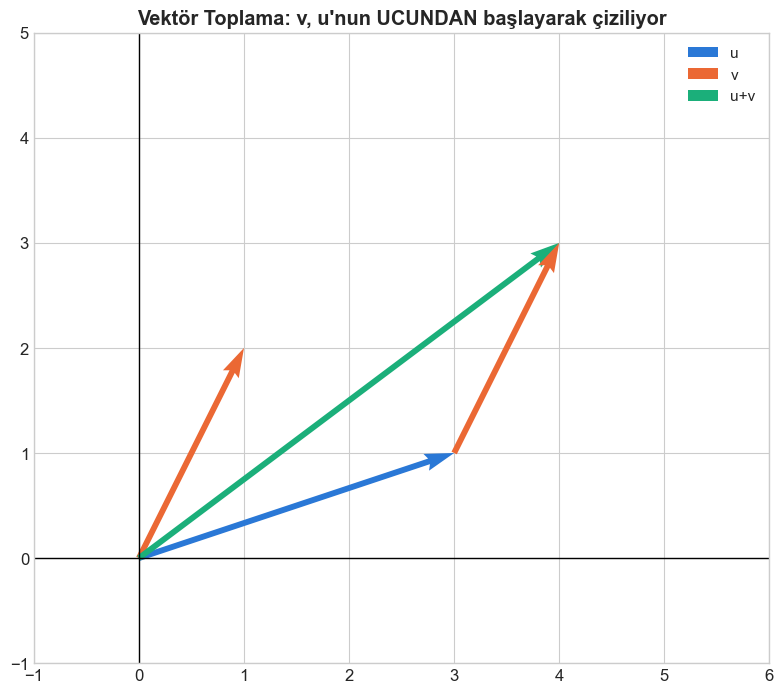

In [7]:
u = np.array([3, 1])
v = np.array([1, 2])

toplam = u + v
iki_kat_u = 2 * u
negatif_v = -v

print(f"u = {u}, v = {v}")
print(f"u + v = {toplam}  (elle: [4,3])")
print(f"2u = {iki_kat_u}  (elle: [6,2])")
print(f"-v = {negatif_v}  (elle: [-1,-2])")

fig, ax = plt.subplots(figsize=(8, 8))

def vektor_ciz(ax, vec, renk, etiket, baslangic=(0,0)):
    ax.quiver(*baslangic, *vec, angles='xy', scale_units='xy', scale=1, color=renk,
               width=0.008, label=etiket)

vektor_ciz(ax, u, '#2a78d6', 'u')
vektor_ciz(ax, v, '#eb6834', 'v')
vektor_ciz(ax, toplam, '#1baf7a', 'u+v')
vektor_ciz(ax, v, '#eb6834', '', baslangic=u)  # v'yi u'nun ucundan baslatarak "uc uca ekleme"yi goster

ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.set_title('Vektör Toplama: v, u\'nun UCUNDAN başlayarak çiziliyor', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 📐 Python 2 — İç Çarpım, Açı ve Projeksiyon

**Ne yapıyoruz?**  
Bölüm 3'teki açı hesabını ($\theta\approx 45°$) doğruluyoruz, ayrıca $\vec{u}$'nun
$\vec{v}$ üzerindeki **projeksiyonunu** (gölgesini) görselleştiriyoruz.

u·v = 5  (elle: 5)
||u|| = 3.1623, ||v|| = 2.2361
cos(θ) = 0.7071
θ = 45.00°  (elle: ~45°)

Projeksiyon katsayısı (u'nun v üzerine düşen 'oranı'): 1.0000
u'nun v üzerindeki projeksiyonu: [1. 2.]
NOT: Bu ozel u,v ciftinde katsayi TAM OLARAK 1 cikti - yani u'nun golgesi,
v'nin TAMAMINI kapliyor (proj_v(u) = v). Bu bir hata degil, sadece bu
sayilarin ozel bir tesadufu - farkli bir u,v ile katsayi genelde 1'den
farkli (0.3, 1.7 gibi) bir sayi cikar.


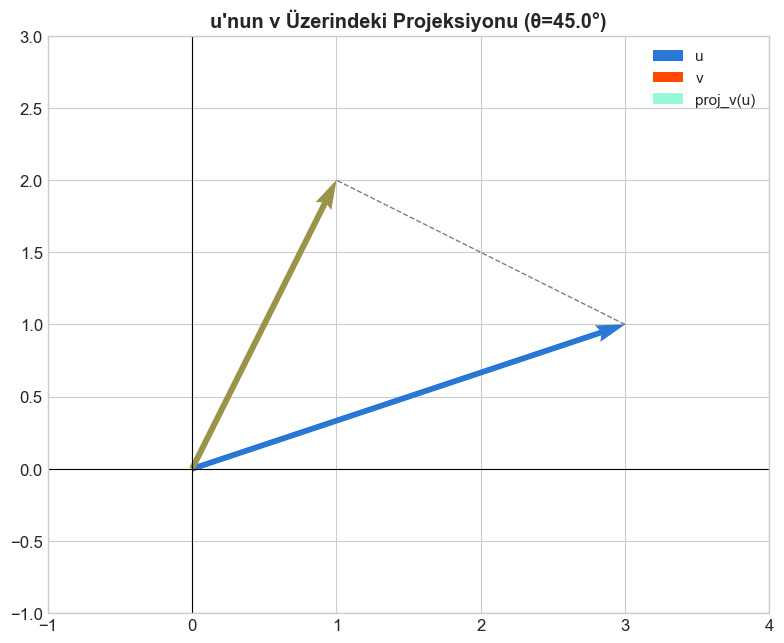


YORUM: Kesikli çizgi, u'dan projeksiyon noktasına DİK iniyor - bu, 'gölge düşürme'
sezgisinin matematiksel garantisi (projeksiyon her zaman orijinal vektöre dik bir
izdüşümdür). Kosinüs benzerliği (cosine similarity) tam olarak bu θ açısının kosinüsü.


In [27]:
ic_carpim = np.dot(u, v) # İç çarpım (dot product)
norm_u = np.linalg.norm(u) # u'nun normu (büyüklüğü, uzunluğu) (||u|| = sqrt(u1^2 + u2^2))
norm_v = np.linalg.norm(v) # v'nin normu (büyüklüğü, uzunluğu) (||v|| = sqrt(v1^2 + v2^2))
cos_theta = ic_carpim / (norm_u * norm_v) # cos(θ) = (u·v) / (||u|| * ||v||)
theta_derece = np.degrees(np.arccos(cos_theta)) # θ açısını derece cinsine çeviriyoruz

print(f"u·v = {ic_carpim}  (elle: 5)")
print(f"||u|| = {norm_u:.4f}, ||v|| = {norm_v:.4f}")
print(f"cos(θ) = {cos_theta:.4f}")
print(f"θ = {theta_derece:.2f}°  (elle: ~45°)")

# u'nun v uzerindeki projeksiyonu: proj_v(u) = (u.v / v.v) * v (Vektörel İzdüşüm)
projeksiyon = (ic_carpim / np.dot(v, v)) * v 
katsayi = ic_carpim / np.dot(v, v) 
print(f"\nProjeksiyon katsayısı (u'nun v üzerine düşen 'oranı'): {katsayi:.4f}")
print(f"u'nun v üzerindeki projeksiyonu: {projeksiyon}")
print("NOT: Bu ozel u,v ciftinde katsayi TAM OLARAK 1 cikti - yani u'nun golgesi,")
print("v'nin TAMAMINI kapliyor (proj_v(u) = v). Bu bir hata degil, sadece bu")
print("sayilarin ozel bir tesadufu - farkli bir u,v ile katsayi genelde 1'den")
print("farkli (0.3, 1.7 gibi) bir sayi cikar.")

fig, ax = plt.subplots(figsize=(8, 8))
vektor_ciz(ax, u, '#2a78d6', 'u')
vektor_ciz(ax, v, "#ff4800", 'v')
vektor_ciz(ax, projeksiyon, "#1ff0a775", 'proj_v(u)')
# projeksiyon cizgisini (u'dan projeksiyonun ucuna dik cizgi) goster
ax.plot([u[0], projeksiyon[0]], [u[1], projeksiyon[1]], 'k--', alpha=0.5, linewidth=1)

ax.set_xlim(-1, 4); ax.set_ylim(-1, 3)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.set_title(f'u\'nun v Üzerindeki Projeksiyonu (θ={theta_derece:.1f}°)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nYORUM: Kesikli çizgi, u'dan projeksiyon noktasına DİK iniyor - bu, 'gölge düşürme'")
print("sezgisinin matematiksel garantisi (projeksiyon her zaman orijinal vektöre dik bir")
print("izdüşümdür). Kosinüs benzerliği (cosine similarity) tam olarak bu θ açısının kosinüsü.")

---
### 🔲 Python 3 — Matris Çarpımı = Lineer Dönüşüm: Birim Kareyi Dönüştürme

**Ne yapıyoruz?**  
Bölüm 5'teki $A=\begin{bmatrix}2&0\\0&3\end{bmatrix}$ örneğini, birim kareyi (4 köşeli bir
şekil) dönüştürerek görselleştiriyoruz — hem tek bir vektörün hem TÜM bir şeklin nasıl
dönüştüğünü göreceksin.

A = 
[[2 0]
 [0 3]]

v=[1,1] -> A@v = [2 3]  (elle: [2,3])


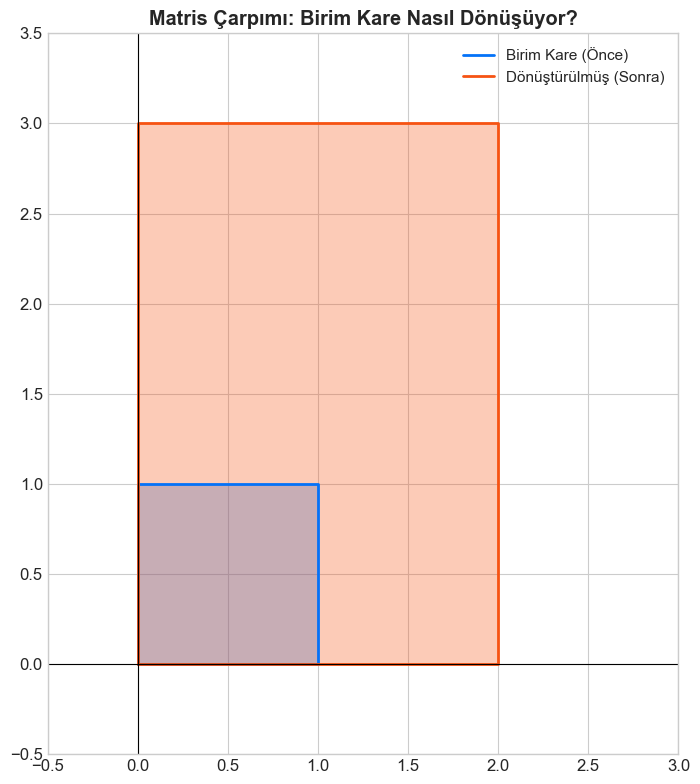


YORUM: Kare, x-yönünde 2 kat, y-yönünde 3 kat uzadı - A'nın diyagonal yapısı
(sadece köşegen elemanlar sıfırdan farklı) TAM OLARAK bunu yapıyor: her ekseni
BAĞIMSIZ olarak ölçeklendiriyor, birbirine karıştırmıyor.


In [16]:
def sekil_ciz(ax, koseler, renk, etiket, alpha=0.3):
    kapali = np.vstack([koseler, koseler[0]])  # sekli kapatmak icin ilk noktaya geri don
    ax.plot(kapali[:, 0], kapali[:, 1], color=renk, linewidth=2, label=etiket)
    ax.fill(kapali[:, 0], kapali[:, 1], color=renk, alpha=alpha)

birim_kare = np.array([[0,0], [1,0], [1,1], [0,1]])

A = np.array([[2, 0], [0, 3]])
donusmus_kare = birim_kare @ A.T  # her satir (nokta) icin A@nokta = nokta@A.T birim_kare ile A matrisini çarpıyoruz


print(f"A = \n{A}")
print(f"\nv=[1,1] -> A@v = {A @ np.array([1,1])}  (elle: [2,3])")

fig, ax = plt.subplots(figsize=(8, 8))
sekil_ciz(ax, birim_kare, "#0472f8", 'Birim Kare (Önce)')
sekil_ciz(ax, donusmus_kare, "#f65313", 'Dönüştürülmüş (Sonra)')

ax.set_xlim(-0.5, 3); ax.set_ylim(-0.5, 3.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.set_title('Matris Çarpımı: Birim Kare Nasıl Dönüşüyor?', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nYORUM: Kare, x-yönünde 2 kat, y-yönünde 3 kat uzadı - A'nın diyagonal yapısı")
print("(sadece köşegen elemanlar sıfırdan farklı) TAM OLARAK bunu yapıyor: her ekseni")
print("BAĞIMSIZ olarak ölçeklendiriyor, birbirine karıştırmıyor.")

---
### 🔄 Python 4 — Özel Dönüşümler Karşılaştırması: Rotasyon, Ölçekleme, Shear, Yansıma

**Ne yapıyoruz?**  
Bölüm 6'daki dört matrisi AYNI şekle (bu sefer bir "ev" — kare + üçgen çatı) uygulayıp,
dördünü yan yana karşılaştırıyoruz.

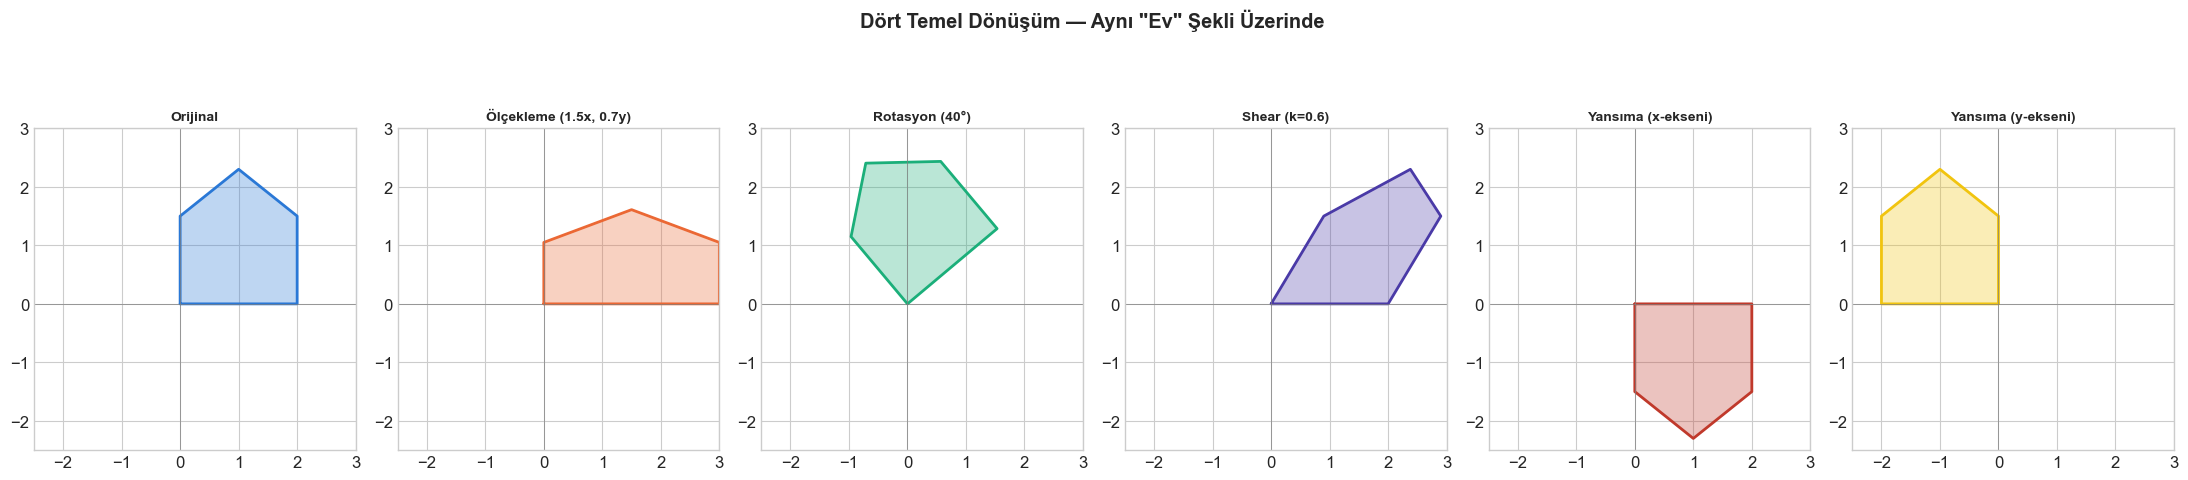

YORUM: Ölçekleme sekli 'gerdi', Rotasyon aynı sekli döndürdü (boyutu DEĞİŞMEDİ),
Shear dikey çizgileri eğik hale getirdi (taban hala yatay), Yansıma evi 'baş aşağı' çevirdi.


In [28]:
# "Ev" sekli: kare govde + ucgen catı (6 kose)
ev = np.array([
    [0, 0], [2, 0], [2, 1.5], [1, 2.3], [0, 1.5]
])

theta = np.radians(40)
donusumler = {
    'Orijinal': np.eye(2), 
    'Ölçekleme (1.5x, 0.7y)': np.array([[1.5, 0], [0, 0.7]]),
    f'Rotasyon ({np.degrees(theta):.0f}°)': np.array([[np.cos(theta), -np.sin(theta)],
                                                          [np.sin(theta), np.cos(theta)]]),
    'Shear (k=0.6)': np.array([[1, 0.6], [0, 1]]),
    'Yansıma (x-ekseni)': np.array([[1, 0], [0, -1]]),
    'Yansıma (y-ekseni)': np.array([[-1, 0], [0, 1]]),
}

fig, axes = plt.subplots(1, 6, figsize=(22, 5))
renkler = ['#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7', '#c0392b', '#f1c40f']

for ax, (isim, M), renk in zip(axes, donusumler.items(), renkler):
    donusmus_ev = ev @ M.T
    kapali = np.vstack([donusmus_ev, donusmus_ev[0]])
    ax.plot(kapali[:, 0], kapali[:, 1], color=renk, linewidth=2)
    ax.fill(kapali[:, 0], kapali[:, 1], color=renk, alpha=0.3)
    ax.set_title(isim, fontsize=10, fontweight='bold')
    ax.set_xlim(-2.5, 3); ax.set_ylim(-2.5, 3)
    ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_aspect('equal')

plt.suptitle('Dört Temel Dönüşüm — Aynı "Ev" Şekli Üzerinde', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("YORUM: Ölçekleme sekli 'gerdi', Rotasyon aynı sekli döndürdü (boyutu DEĞİŞMEDİ),")
print("Shear dikey çizgileri eğik hale getirdi (taban hala yatay), Yansıma evi 'baş aşağı' çevirdi.")

---
### 📏 Python 5 — Determinant = Alan Ölçekleme Kanıtı

**Ne yapıyoruz?**  
Bölüm 7'deki iddiayı ("determinant = alan ölçekleme faktörü") 3 farklı matrisle test edip,
her birinde dönüştürülmüş şeklin alanını `determinant` ile karşılaştırıyoruz.

In [18]:
from numpy.linalg import det

def poligon_alani(koseler):
    # Shoelace formulu ile herhangi bir poligonun alanini hesapla
    x = koseler[:, 0]; y = koseler[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

test_matrisleri = {
    'A1 (ölçekleme)': np.array([[2, 0], [0, 3]]),
    'A2 (shear)': np.array([[1, 0.6], [0, 1]]),
    'A3 (yansıma+ölçek)': np.array([[2, 0], [0, -1.5]]),
}

birim_kare_alani = poligon_alani(birim_kare)
print(f"Birim karenin alanı: {birim_kare_alani}\n")

for isim, M in test_matrisleri.items():
    donusmus = birim_kare @ M.T
    yeni_alan = poligon_alani(donusmus)
    determinant = det(M)
    print(f"{isim}: det(M)={determinant:.2f}, |det(M)|={abs(determinant):.2f}, "
          f"gerçek yeni alan={yeni_alan:.2f}  {'✓ EŞİT' if abs(abs(determinant)-yeni_alan)<1e-9 else '✗'}")

print("\nYORUM: |det(M)| ile gerçek alan HER SEFERİNDE birebir eşleşiyor - determinantın")
print("'alan ölçekleme faktörü' olduğu iddiası sayısal olarak kanıtlandı. A3'te determinant")
print("NEGATİF çıkıyor (yansıma var) ama alan her zaman pozitif olduğu için mutlak değerini alıyoruz.")

Birim karenin alanı: 1.0

A1 (ölçekleme): det(M)=6.00, |det(M)|=6.00, gerçek yeni alan=6.00  ✓ EŞİT
A2 (shear): det(M)=1.00, |det(M)|=1.00, gerçek yeni alan=1.00  ✓ EŞİT
A3 (yansıma+ölçek): det(M)=-3.00, |det(M)|=3.00, gerçek yeni alan=3.00  ✓ EŞİT

YORUM: |det(M)| ile gerçek alan HER SEFERİNDE birebir eşleşiyor - determinantın
'alan ölçekleme faktörü' olduğu iddiası sayısal olarak kanıtlandı. A3'te determinant
NEGATİF çıkıyor (yansıma var) ama alan her zaman pozitif olduğu için mutlak değerini alıyoruz.


---
### ↩️ Python 6 — Matris Tersi ve Tekil (Singular) Matris

**Ne yapıyoruz?**  
Önce normal bir matrisi dönüştürüp tersini alarak ORİJİNALE geri dönebildiğimizi kanıtlıyoruz.
Sonra **determinantı sıfır olan** bir matrisi deneyip, karenin gerçekten bir ÇİZGİYE
sıkıştığını ve tersinin neden var olamayacağını görsel olarak kanıtlıyoruz.

det(A_normal) = 5.00 (sıfır değil, tersi var)
A_normal:
[[2 1]
 [1 3]]
A_normal^-1:
[[ 0.6 -0.2]
 [-0.2  0.4]]

Dönüştürülmüş kare köşeleri:
[[0 0]
 [2 1]
 [3 4]
 [1 3]]

Dönüştürülmüş kare köşeleri TERSİYLE geri alındı:
[[ 0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  1.00000000e+00]
 [-5.55111512e-17  1.00000000e+00]]
Orijinal kare köşeleri:
[[0 0]
 [1 0]
 [1 1]
 [0 1]]

Dönüştürülmüş, sonra TERSİYLE geri alınmış köşeler:
[[ 0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  1.00000000e+00]
 [-5.55111512e-17  1.00000000e+00]]
Birebir aynı mı? EVET ✓

det(A_tekil) = 0.00


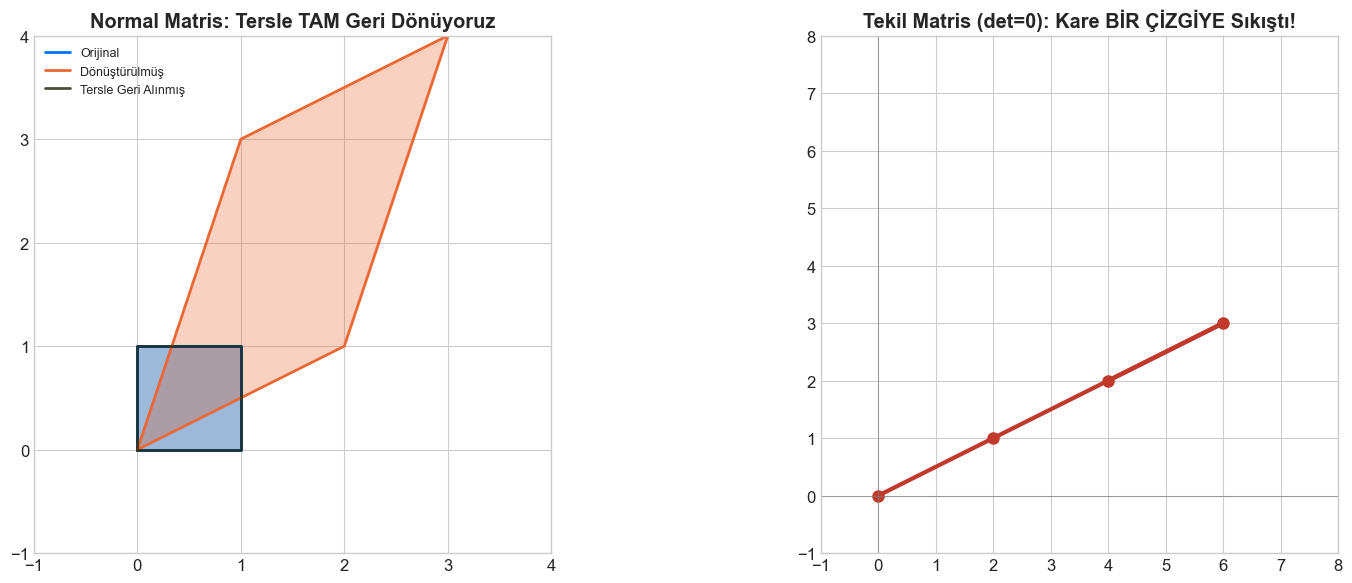


YORUM: Tekil matriste tüm kare köşeleri TEK BİR ÇİZGİ üzerine düştü - 2D bilgi,
1D'ye sıkıştırıldı (bilgi kaybı). Bu noktadan 'hangi orijinal köşeden geldiğini'
artık bilemezsin - bu yüzden matematiksel olarak tersi YOK.


In [55]:
A_normal = np.array([[2, 1], [1, 3]])
print(f"det(A_normal) = {det(A_normal):.2f} (sıfır değil, tersi var)")

A_inv = np.linalg.inv(A_normal) # linalg.inv ile A_normal'in tersini alıyoruz
print(f"A_normal:\n{A_normal}\nA_normal^-1:\n{A_inv}")
donusmus = birim_kare @ A_normal.T # her satir (nokta) icin A@nokta = nokta@A.T
print(f"\nDönüştürülmüş kare köşeleri:\n{donusmus}")
geri_alinmis = donusmus @ A_inv.T # her satir (nokta) icin A_inv@nokta = nokta@A_inv.T
print(f"\nDönüştürülmüş kare köşeleri TERSİYLE geri alındı:\n{geri_alinmis}")

print(f"Orijinal kare köşeleri:\n{birim_kare}")
print(f"\nDönüştürülmüş, sonra TERSİYLE geri alınmış köşeler:\n{geri_alinmis}")
print(f"Birebir aynı mı? {'EVET ✓' if np.allclose(birim_kare, geri_alinmis) else 'HAYIR'}")

A_tekil = np.array([[2, 4], [1, 2]])
print(f"\ndet(A_tekil) = {det(A_tekil):.2f}")

donusmus_tekil = birim_kare @ A_tekil.T

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sekil_ciz(axes[0], birim_kare, "#0073ff", 'Orijinal')
sekil_ciz(axes[0], donusmus, '#eb6834', 'Dönüştürülmüş')
sekil_ciz(axes[0], geri_alinmis, "#1f2307cc", 'Tersle Geri Alınmış', alpha=0.15)
axes[0].set_title('Normal Matris: Tersle TAM Geri Dönüyoruz', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_aspect('equal')
axes[0].set_xlim(-1, 4); axes[0].set_ylim(-1, 4)

axes[1].plot(donusmus_tekil[:, 0], donusmus_tekil[:, 1], 'o-', color='#c0392b', linewidth=3, markersize=8)
axes[1].set_title('Tekil Matris (det=0): Kare BİR ÇİZGİYE Sıkıştı!', fontweight='bold')
axes[1].set_aspect('equal')
axes[1].set_xlim(-1, 8); axes[1].set_ylim(-1, 8)
axes[1].axhline(0, color='gray', linewidth=0.5); axes[1].axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nYORUM: Tekil matriste tüm kare köşeleri TEK BİR ÇİZGİ üzerine düştü - 2D bilgi,")
print("1D'ye sıkıştırıldı (bilgi kaybı). Bu noktadan 'hangi orijinal köşeden geldiğini'")
print("artık bilemezsin - bu yüzden matematiksel olarak tersi YOK.")

---
### 🔗 Python 7 — Gerçek Kullanım: Dönüşümleri Zincirleme

**Ne yapıyoruz?**  
Bilgisayar grafiklerinde/robotikte, genelde TEK bir dönüşüm değil, **birden fazla dönüşümü
sırayla** uygularsın (örn. bir nesneyi önce döndür, sonra ölçekle, sonra kaydır). Kritik
matematiksel gerçek: **ardışık dönüşümler, matrislerin ÇARPIMI ile TEK bir matrise
birleştirilebilir** — $A(B\vec{v}) = (AB)\vec{v}$. Bunu somut olarak kanıtlayacağız.

Sırayla uygulanan sonuç (ilk 3 köşe):
[[0.         0.        ]
 [2.83807621 0.8       ]
 [2.02484536 1.83923048]]

Birleştirilmiş matrisle TEK SEFERDE uygulanan sonuç (ilk 3 köşe):
[[0.         0.        ]
 [2.83807621 0.8       ]
 [2.02484536 1.83923048]]

İki yöntem birebir aynı mı? EVET ✓


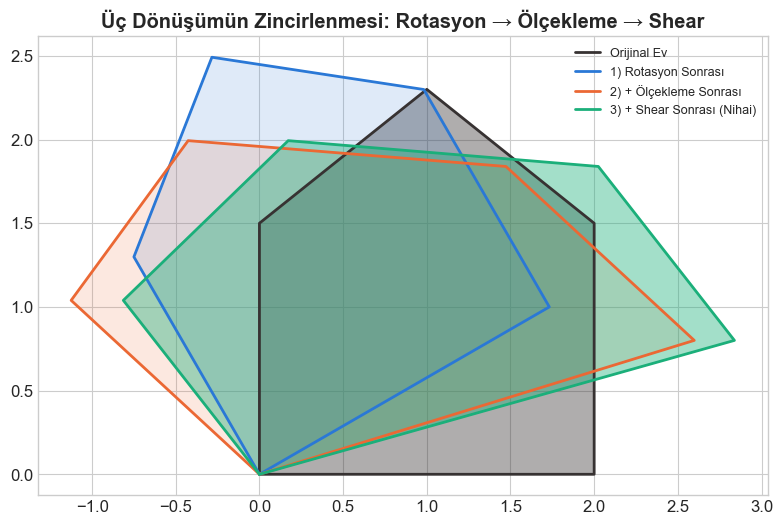


YORUM: Bu, gerçek yazılımlarda (oyun motorları, CAD programları, robot kinematiği)
NEDEN her nesne için TEK bir 'dönüşüm matrisi' saklandığının sebebi - onlarca ardışık
işlemi TEK bir matris çarpımına sıkıştırıp çok daha hızlı hesaplayabiliyorsun.
NOT: Sıra ÖNEMLİ - A@B genelde B@A'ya eşit DEĞİLDİR (matris çarpımı komütatif değil),
yani 'önce döndür sonra ölçekle' ile 'önce ölçekle sonra döndür' FARKLI sonuçlar verir.


In [34]:
rotasyon = np.array([[np.cos(np.radians(30)), -np.sin(np.radians(30))],
                       [np.sin(np.radians(30)), np.cos(np.radians(30))]])
olcekleme = np.array([[1.5, 0], [0, 0.8]])
kaydirma_shear = np.array([[1, 0.3], [0, 1]])

# YONTEM 1: Uc donusumu SIRAYLA, ayri ayri uygula
adim1 = ev @ rotasyon.T
adim2 = adim1 @ olcekleme.T
adim3_sirali = adim2 @ kaydirma_shear.T

# YONTEM 2: Once UC matrisi CARP, sonra TEK seferde uygula
birlesik_matris = kaydirma_shear @ olcekleme @ rotasyon
adim3_birlesik = ev @ birlesik_matris.T

print("Sırayla uygulanan sonuç (ilk 3 köşe):")
print(adim3_sirali[:3])
print("\nBirleştirilmiş matrisle TEK SEFERDE uygulanan sonuç (ilk 3 köşe):")
print(adim3_birlesik[:3])
print(f"\nİki yöntem birebir aynı mı? {'EVET ✓' if np.allclose(adim3_sirali, adim3_birlesik) else 'HAYIR'}")

fig, ax = plt.subplots(figsize=(8, 8))
sekil_ciz(ax, ev, "#373232", 'Orijinal Ev', alpha=0.4)
sekil_ciz(ax, adim1, '#2a78d6', '1) Rotasyon Sonrası', alpha=0.15)
sekil_ciz(ax, adim2, '#eb6834', '2) + Ölçekleme Sonrası', alpha=0.15)
sekil_ciz(ax, adim3_sirali, '#1baf7a', '3) + Shear Sonrası (Nihai)', alpha=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Üç Dönüşümün Zincirlenmesi: Rotasyon → Ölçekleme → Shear', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nYORUM: Bu, gerçek yazılımlarda (oyun motorları, CAD programları, robot kinematiği)")
print("NEDEN her nesne için TEK bir 'dönüşüm matrisi' saklandığının sebebi - onlarca ardışık")
print("işlemi TEK bir matris çarpımına sıkıştırıp çok daha hızlı hesaplayabiliyorsun.")
print("NOT: Sıra ÖNEMLİ - A@B genelde B@A'ya eşit DEĞİLDİR (matris çarpımı komütatif değil),")
print("yani 'önce döndür sonra ölçekle' ile 'önce ölçekle sonra döndür' FARKLI sonuçlar verir.")

---
## ✏️ Egzersizler

---

### **E1.**
$\vec{a}=[2,5]$, $\vec{b}=[4,-1]$ için: $\vec{a}+\vec{b}$, $3\vec{a}-\vec{b}$, iç
çarpımı, ve aralarındaki açıyı elle hesapla. `numpy` ile doğrula.

In [35]:
print("\n==== Egzersiz 1: İki vektörde İşlemler ====")

a = np.array([2, 5])
b = np.array([4, -1])

a_b_toplam = a + b

uc_kat_a = 3 * a

uca_b_cikarma = 3 * a - b

ic_carpim_ab = np.dot(a, b)

cos_theta_ab = ic_carpim_ab / (np.linalg.norm(a) * np.linalg.norm(b))

print(f"a = {a}, b = {b}")
print(f"a + b = {a_b_toplam}")
print(f"3a = {uc_kat_a}")
print(f"3a - b = {uca_b_cikarma}")
print(f"a·b = {ic_carpim_ab}")
print(f"cos(θ) = {cos_theta_ab:.4f}")


==== Egzersiz 1: İki vektörde İşlemler ====
a = [2 5], b = [ 4 -1]
a + b = [6 4]
3a = [ 6 15]
3a - b = [ 2 16]
a·b = 3
cos(θ) = 0.1351


---

### **E2.**
$M=\begin{bmatrix}0&-1\\1&0\end{bmatrix}$ matrisinin hangi özel dönüşüme (Bölüm 6'daki
dörtlüden) karşılık geldiğini bul (ipucu: $\cos\theta$ ve $\sin\theta$ formülleriyle
karşılaştır). Python 4'teki "ev" şekline uygulayıp görselleştir.


 ==== Egzersiz 2: Matris Dönüşümleri ====
M = 
[[ 0 -1]
 [ 1  0]]

Rotasyon 90°:
[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]
M ile Rotasyon 90° aynı mı?  EVET ✓

Ev:
[[0.  0. ]
 [2.  0. ]
 [2.  1.5]
 [1.  2.3]
 [0.  1.5]]

Dönüştürülmüş Ev (M ile):
[[ 0.   0. ]
 [ 0.   2. ]
 [-1.5  2. ]
 [-2.3  1. ]
 [-1.5  0. ]]

Dönüştürülmüş Ev (Rotasyon 90° ile):
[[ 0.00000000e+00  0.00000000e+00]
 [ 1.22464680e-16  2.00000000e+00]
 [-1.50000000e+00  2.00000000e+00]
 [-2.30000000e+00  1.00000000e+00]
 [-1.50000000e+00  9.18485099e-17]]


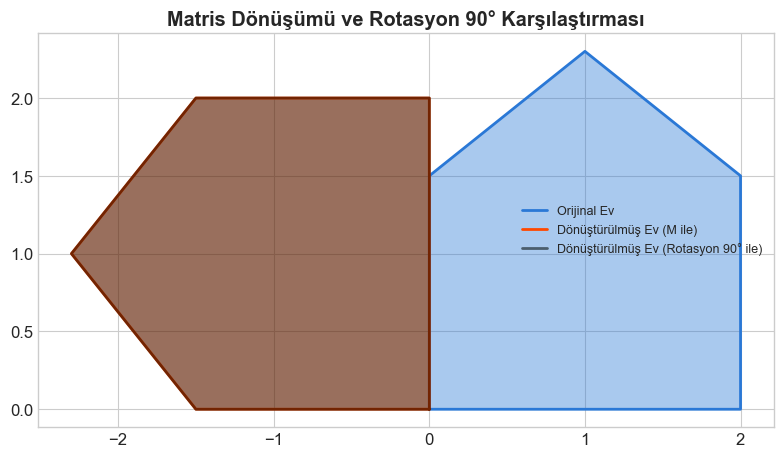

In [47]:
print("\n ==== Egzersiz 2: Matris Dönüşümleri ====")

M = np.array([[0, -1], [1, 0]])

print(f"M = \n{M}")

rotasyon_90 = np.array([[np.cos(np.radians(90)), -np.sin(np.radians(90))],
                        [np.sin(np.radians(90)), np.cos(np.radians(90))]])

print(f"\nRotasyon 90°:\n{rotasyon_90}")

print("M ile Rotasyon 90° aynı mı? ", "EVET ✓" if np.allclose(M, rotasyon_90) else "HAYIR ✗")

ev = np.array([[0, 0], [2, 0], [2, 1.5], [1, 2.3], [0, 1.5]])

print(f"\nEv:\n{ev}")

donusmus_ev = ev @ M.T
print(f"\nDönüştürülmüş Ev (M ile):\n{donusmus_ev}")

rotasyon_90_ev = ev @ rotasyon_90.T
print(f"\nDönüştürülmüş Ev (Rotasyon 90° ile):\n{rotasyon_90_ev}")

fig, ax = plt.subplots(figsize=(8, 8))
sekil_ciz(ax, ev, "#2a78d6", 'Orijinal Ev', alpha=0.4)
sekil_ciz(ax, donusmus_ev, "#ff4800", 'Dönüştürülmüş Ev (M ile)', alpha=0.4)
sekil_ciz(ax, rotasyon_90_ev, "#0008058d", 'Dönüştürülmüş Ev (Rotasyon 90° ile)', alpha=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Matris Dönüşümü ve Rotasyon 90° Karşılaştırması', fontweight='bold')
plt.tight_layout()
plt.show()

---

### **E3.**
Python 7'deki üç dönüşümü TERS SIRAYLA (önce shear, sonra ölçekleme, sonra
rotasyon) uygula. Sonuç, orijinal sıradaki sonuçla AYNI MI çıkıyor? (Yorumundaki
"komütatif değil" iddiasını kendi örneğinle doğrula.)


 ==== Egzersiz 3: Önce Shear Sonra Ölçekle Sonra Rotasyon ====


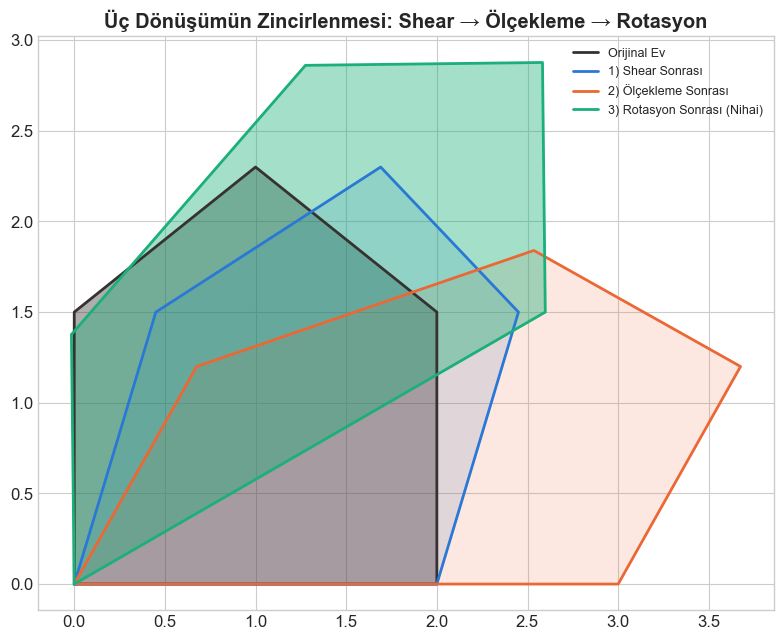

In [50]:
print("\n ==== Egzersiz 3: Önce Shear Sonra Ölçekle Sonra Rotasyon ====")
rotasyon_30 = np.array([[np.cos(np.radians(30)), -np.sin(np.radians(30))],
                        [np.sin(np.radians(30)), np.cos(np.radians(30))]])
olcekleme = np.array([[1.5, 0], [0, 0.8]])
shear = np.array([[1, 0.3], [0, 1]])

adim1_farkli = ev @ shear.T
adim2_farkli = adim1_farkli @ olcekleme.T
adim3_farkli = adim2_farkli @ rotasyon_30.T

birlesik_matris_farkli = rotasyon_30 @ olcekleme @ shear
adim3_birlesik_farkli = ev @ birlesik_matris_farkli.T

fig, ax = plt.subplots(figsize=(8, 8))
sekil_ciz(ax, ev, "#373232", 'Orijinal Ev', alpha=0.4)
sekil_ciz(ax, adim1_farkli, '#2a78d6', '1) Shear Sonrası', alpha=0.15)
sekil_ciz(ax, adim2_farkli, '#eb6834', '2) Ölçekleme Sonrası', alpha=0.15)
sekil_ciz(ax, adim3_farkli, '#1baf7a', '3) Rotasyon Sonrası (Nihai)', alpha=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.set_title('Üç Dönüşümün Zincirlenmesi: Shear → Ölçekleme → Rotasyon', fontweight='bold')
plt.tight_layout()
plt.show()

---

### **E4.**
Determinantı tam olarak $0$ olan (ama Python 6'dakinden farklı) bir $2\times 2$
matris bul, birim kareye uygulayıp görselleştir — hangi çizgiye sıkıştığını gözlemle.


 ==== Egzersiz 4: Determinant 0 Olan Matris ====
A_tekil = 
[[1 3]
 [1 3]]
det(A_tekil) = 0.00 (sıfır, yani tekil)

Dönüştürülmüş kare köşeleri (tekil matris ile):
[[0 0]
 [1 1]
 [4 4]
 [3 3]]


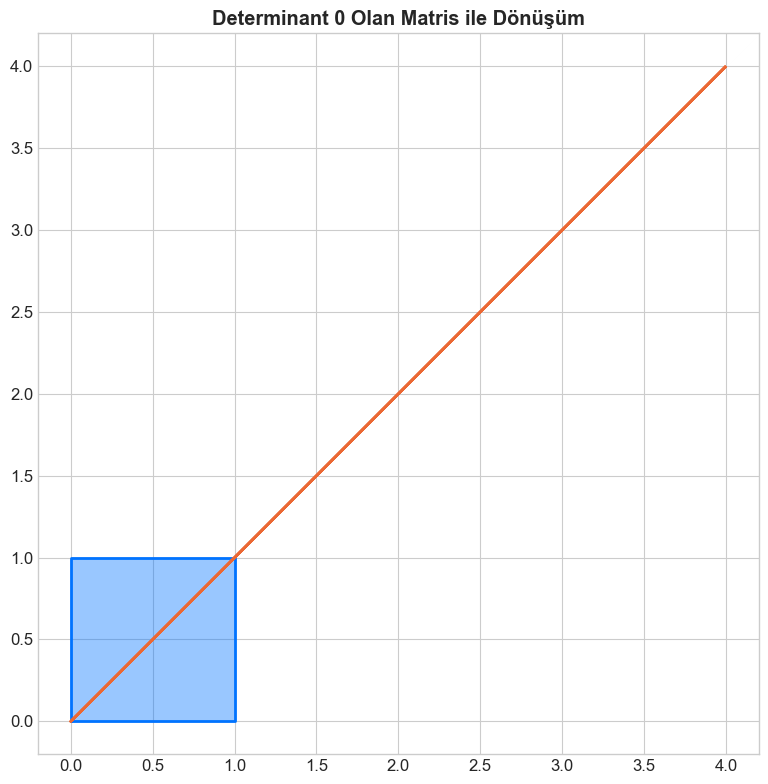

In [53]:
print("\n ==== Egzersiz 4: Determinant 0 Olan Matris ====")

A_tekil = np.array([[1, 3], [1, 3]])  # Bu matrisin determinantı 0'dır

determinant_tekil = det(A_tekil)
print(f"A_tekil = \n{A_tekil}")
print(f"det(A_tekil) = {determinant_tekil:.2f} (sıfır, yani tekil)")

birim_kare = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
donusmus_tekil = birim_kare @ A_tekil.T
print(f"\nDönüştürülmüş kare köşeleri (tekil matris ile):\n{donusmus_tekil}")

fig, ax = plt.subplots(figsize=(8, 8))
sekil_ciz(ax, birim_kare, "#0073ff", 'Orijinal Birim Kare', alpha=0.4)
sekil_ciz(ax, donusmus_tekil, '#eb6834', 'Dönüştürülmüş (Tekil Matris)', alpha=0.4)
ax.set_aspect('equal')
ax.set_title('Determinant 0 Olan Matris ile Dönüşüm', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Essence of Linear Algebra](https://www.3blue1brown.com/topics/linear-algebra) | Bölüm 1-5 | Bu notebook'un TEK EN ÖNEMLİ referansı — görsel sezgi birebir örtüşüyor |
| [MIT 18.06 — Gilbert Strang](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/) | Ders 1-5 | Klasik, kapsamlı üniversite dersi |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 2 | Vektör/matris temelleri, ML bağlamında |
| [setosa.io — Matris Çarpımı](https://setosa.io/matrix-multiplication/) | — | İnteraktif matris çarpımı görselleştirmesi |
| [NumPy `linalg` Dokümantasyonu](https://numpy.org/doc/stable/reference/routines.linalg.html) | Kütüphane | Bu notebook'ta kullanılan ana araç |